In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import pickle
import os

SAVE_DIR = '/content/drive/MyDrive/GameRecommender/save'
DATA_PATH = '/content/drive/MyDrive/GameRecommender/updated_filtered_game_data.csv'
BATCH_SIZE = 128
LATENT_DIM = 128
EPOCHS = 50
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:

# load data
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} games")

# Dien cot bi thieu thong tin
df['Detailed description'] = df['Detailed description'].fillna("")
df['Short description'] = df['Short description'].fillna("")

Loaded 30000 games


In [5]:
# Data Exploration
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AppID                 30000 non-null  int64  
 1   Name                  30000 non-null  object 
 2   Release date          30000 non-null  object 
 3   Price                 30000 non-null  float64
 4   Detailed description  30000 non-null  object 
 5   Short description     30000 non-null  object 
 6   Header image          30000 non-null  object 
 7   Developers            30000 non-null  object 
 8   Publishers            29809 non-null  object 
 9   Categories            30000 non-null  object 
 10  Genres                30000 non-null  object 
 11  Tags                  30000 non-null  object 
 12  Positive              30000 non-null  int64  
 13  Negative              30000 non-null  int64  
 14  Total Reviews         30000 non-null  int64  
 15  Mov

In [6]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
              AppID         Price      Positive       Negative  Total Reviews
count  3.000000e+04  30000.000000  3.000000e+04   30000.000000   3.000000e+04
mean   9.002979e+05      9.948447  2.748180e+03     455.247867   3.203428e+03
std    5.841443e+05     11.366238  4.114783e+04    7699.579754   4.741112e+04
min    1.000000e+01      0.000000  1.000000e+00       0.000000   2.800000e+01
25%    4.346575e+05      1.990000  4.200000e+01      11.000000   5.800000e+01
50%    7.792750e+05      6.990000  1.090000e+02      31.000000   1.460000e+02
75%    1.255070e+06     14.990000  4.492500e+02     110.000000   5.720000e+02
max    3.161850e+06    299.900000  5.764420e+06  895978.000000   6.531097e+06


In [7]:
print("\nSample Data:")
print(df.head())


Sample Data:
    AppID                              Name  Release date  Price  \
0     730  Counter-Strike: Global Offensive  Aug 21, 2012   0.00   
1  578080               PUBG: BATTLEGROUNDS  Dec 21, 2017   0.00   
2     570                            Dota 2   Jul 9, 2013   0.00   
3  271590                Grand Theft Auto V  Apr 13, 2015   0.00   
4  359550   Tom Clancy's Rainbow Six® Siege   Dec 1, 2015  19.99   

                                Detailed description  \
0  Counter-Strike: Global Offensive (CS: GO) expa...   
1  LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...   
2  The most-played game on Steam. Every day, mill...   
3  When a young street hustler, a retired bank ro...   
4  Y7 Pass Edition Comparison Deluxe Edition Oper...   

                                   Short description  \
0  Counter-Strike: Global Offensive (CS: GO) expa...   
1  Play PUBG: BATTLEGROUNDS for free. Land on str...   
2  Every day, millions of players worldwide enter...   
3  Grand Theft A

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
AppID                      0
Name                       0
Release date               0
Price                      0
Detailed description       0
Short description          0
Header image               0
Developers                 0
Publishers               191
Categories                 0
Genres                     0
Tags                       0
Positive                   0
Negative                   0
Total Reviews              0
Movies                  1639
Link Game                  0
dtype: int64


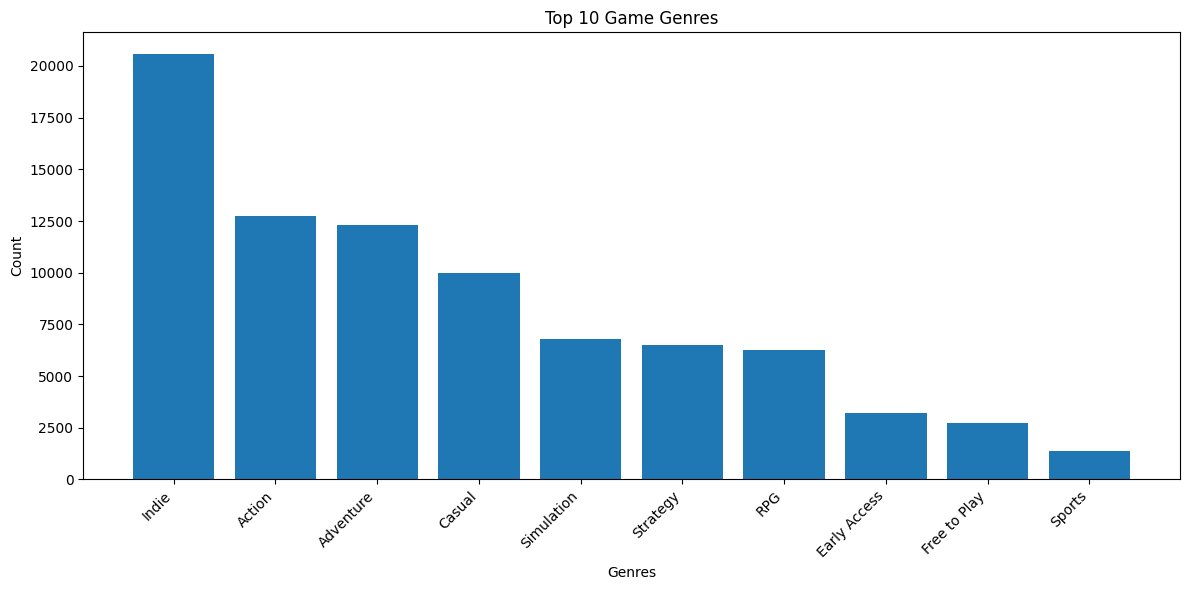

In [14]:
# The loai
from collections import Counter
import matplotlib.pyplot as plt

all_genres = [genre for genres in df['Genres'] for genre in genres]
genre_counts = Counter(all_genres)
top_genres = dict(genre_counts.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_genres.keys(), top_genres.values())
plt.title('Top 10 Game Genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
def parse_list_column(series):
    """Parse string representation of lists"""
    return series.fillna('[]').apply(lambda x: eval(x) if isinstance(x, str) else x)

# Parse categorical features
df['Genres'] = parse_list_column(df['Genres'])
df['Tags'] = parse_list_column(df['Tags'])
df['Categories'] = parse_list_column(df['Categories'])

# Encode categorical features
mlb_genres = MultiLabelBinarizer()
genres_matrix = mlb_genres.fit_transform(df['Genres']).astype(np.float32)

mlb_tags = MultiLabelBinarizer()
tags_matrix = mlb_tags.fit_transform(df['Tags']).astype(np.float32)

mlb_categories = MultiLabelBinarizer()
categories_matrix = mlb_categories.fit_transform(df['Categories']).astype(np.float32)

print(f"Genres: {genres_matrix.shape[1]} features")
print(f"Tags: {tags_matrix.shape[1]} features")
print(f"Categories: {categories_matrix.shape[1]} features")

Genres: 29 features
Tags: 450 features
Categories: 42 features


In [10]:
#  BERT EMBEDDINGS
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(DEVICE)
bert_model.eval()

def get_bert_embeddings(texts, batch_size=16):
    """Get BERT embeddings with progress bar"""
    embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="BERT embeddings"):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                return_tensors='pt',
                truncation=True,
                padding=True,
                max_length=128
            ).to(DEVICE)

            outputs = bert_model(**inputs)
            # Use [CLS] token representation
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

# Combine description fields for richer context
df['combined_desc'] = df['Detailed description'] + " " + df['Short description']
desc_embeddings = get_bert_embeddings(df['combined_desc'].tolist())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT embeddings: 100%|██████████| 1875/1875 [05:54<00:00,  5.29it/s]


In [11]:

print(f"Description embeddings: {desc_embeddings.shape}")

Description embeddings: (30000, 768)


In [12]:
#FEATURE COMBINATION
# Weight important features
GENRE_WEIGHT = 2.0
TAG_WEIGHT = 1.5
CATEGORY_WEIGHT = 1.0
DESC_WEIGHT = 1.0

features = np.hstack([
    genres_matrix * GENRE_WEIGHT,
    tags_matrix * TAG_WEIGHT,
    categories_matrix * CATEGORY_WEIGHT,
    desc_embeddings * DESC_WEIGHT
])

print(f"Combined features shape: {features.shape}")

# Normalize features - QUAN TRỌNG!
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features = scaler.fit_transform(features)

# Check feature range
print(f"Feature range: [{features.min():.4f}, {features.max():.4f}]")
print(f"Feature mean: {features.mean():.4f}, std: {features.std():.4f}")

# Convert to tensor
features_tensor = torch.FloatTensor(features).to(DEVICE)

Combined features shape: (30000, 1289)
Feature range: [0.0000, 1.0000]
Feature mean: 0.3158, std: 0.2757


In [15]:


class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=128):
        super(ImprovedAutoencoder, self).__init__()

        # Encoder with residual connections
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),

            nn.Linear(256, latent_dim),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, input_dim),
            nn.Sigmoid()  # Đảm bảo output trong [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def encode(self, x):
        return self.encoder(x)

In [16]:
#train
model = ImprovedAutoencoder(
    input_dim=features.shape[1],
    latent_dim=LATENT_DIM
).to(DEVICE)

# Khởi tạo weights
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.MSELoss()

# Learning rate scheduler - giảm aggressive
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

# Training loop
losses = []
best_loss = float('inf')
patience_counter = 0
max_patience = 10

print("\nStarting training...")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    num_batches = 0

    # Mini-batch training
    for i in range(0, len(features_tensor), BATCH_SIZE):
        batch = features_tensor[i:i+BATCH_SIZE]

        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)

    # Update learning rate
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Print if LR changed
    if old_lr != new_lr:
        print(f"→ Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
    else:
        patience_counter += 1

    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.6f}, Best: {best_loss:.6f}, LR: {new_lr:.7f}")

    # Early stopping
    if patience_counter >= max_patience:
        print(f"\n⚠️  Early stopping at epoch {epoch+1}")
        break

print(f"\n✓ Training completed!")
print(f"✓ Best loss: {best_loss:.6f}")


Starting training...
Total parameters: 4,028,297
Epoch 1/50, Loss: 0.018954, Best: 0.018954, LR: 0.0010000
Epoch 5/50, Loss: 0.010384, Best: 0.010384, LR: 0.0010000
Epoch 10/50, Loss: 0.009593, Best: 0.009593, LR: 0.0010000
Epoch 15/50, Loss: 0.009206, Best: 0.009206, LR: 0.0010000
Epoch 20/50, Loss: 0.008966, Best: 0.008966, LR: 0.0010000
Epoch 25/50, Loss: 0.008802, Best: 0.008802, LR: 0.0010000
Epoch 30/50, Loss: 0.008674, Best: 0.008674, LR: 0.0010000
Epoch 35/50, Loss: 0.008584, Best: 0.008584, LR: 0.0010000
Epoch 40/50, Loss: 0.008496, Best: 0.008496, LR: 0.0010000
Epoch 45/50, Loss: 0.008423, Best: 0.008423, LR: 0.0010000
Epoch 50/50, Loss: 0.008364, Best: 0.008364, LR: 0.0010000

✓ Training completed!
✓ Best loss: 0.008364


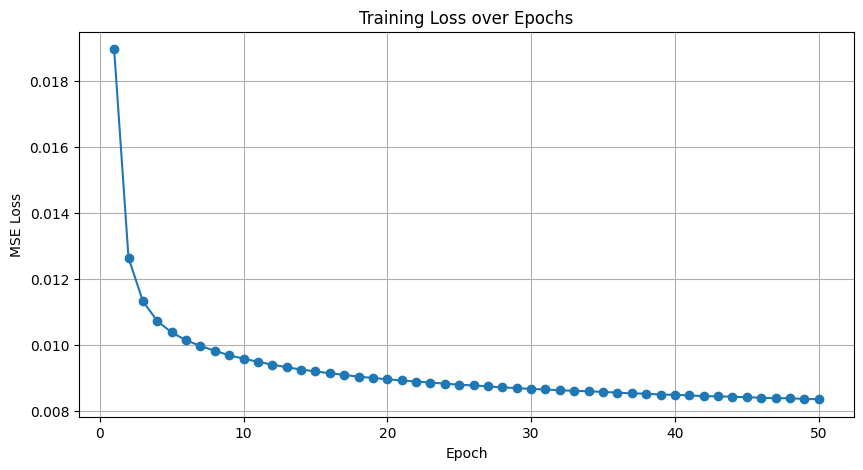

Training loss plot saved!


<Figure size 640x480 with 0 Axes>

In [17]:
# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# Save loss plot
plt.savefig(os.path.join(SAVE_DIR, 'training_loss.png'))
print("Training loss plot saved!")

In [18]:
#  EXTRACT LATENT REPRESENTATIONS
model.eval()
with torch.no_grad():
    latent_reps = model.encode(features_tensor).cpu().numpy()

print(f"Latent representations shape: {latent_reps.shape}")

Latent representations shape: (30000, 128)


In [23]:
# Model Summary
from torchsummary import summary

print("\nModel Architecture:")
summary(model, input_size=(features.shape[1],))


Model Architecture:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1024]       1,320,960
       BatchNorm1d-2                 [-1, 1024]           2,048
         LeakyReLU-3                 [-1, 1024]               0
           Dropout-4                 [-1, 1024]               0
            Linear-5                  [-1, 512]         524,800
       BatchNorm1d-6                  [-1, 512]           1,024
         LeakyReLU-7                  [-1, 512]               0
           Dropout-8                  [-1, 512]               0
            Linear-9                  [-1, 256]         131,328
      BatchNorm1d-10                  [-1, 256]             512
        LeakyReLU-11                  [-1, 256]               0
          Dropout-12                  [-1, 256]               0
           Linear-13                  [-1, 128]          32,896
           Linear-

In [19]:

# Save model
torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'autoencoder_model.pth'))

# Save latent representations
np.save(os.path.join(SAVE_DIR, 'latent_reps.npy'), latent_reps)

# Save preprocessing objects
with open(os.path.join(SAVE_DIR, 'mlb_genres.pkl'), 'wb') as f:
    pickle.dump(mlb_genres, f)
with open(os.path.join(SAVE_DIR, 'mlb_tags.pkl'), 'wb') as f:
    pickle.dump(mlb_tags, f)
with open(os.path.join(SAVE_DIR, 'mlb_categories.pkl'), 'wb') as f:
    pickle.dump(mlb_categories, f)
with open(os.path.join(SAVE_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

In [20]:
# Save processed dataframe
df.to_csv(os.path.join(SAVE_DIR, 'processed_games.csv'), index=False)

# Save feature weights for later use
feature_info = {
    'input_dim': features.shape[1],
    'latent_dim': LATENT_DIM,
    'genre_weight': GENRE_WEIGHT,
    'tag_weight': TAG_WEIGHT,
    'category_weight': CATEGORY_WEIGHT,
    'desc_weight': DESC_WEIGHT
}
with open(os.path.join(SAVE_DIR, 'feature_info.pkl'), 'wb') as f:
    pickle.dump(feature_info, f)

print("\n Training completed!")
print(f"Best loss: {best_loss:.6f}")
print(f" All files saved to {SAVE_DIR}")






 Training completed!
Best loss: 0.008364
 All files saved to /content/drive/MyDrive/GameRecommender/save


In [24]:
# Test recommendation for first game
test_game = df['Name'].iloc[1]
test_idx = 0
similarities = cosine_similarity([latent_reps[test_idx]], latent_reps)[0]
top_indices = similarities.argsort()[-6:-1][::-1]

print(f"\nTop 5 recommendations for '{test_game}':")
for i, idx in enumerate(top_indices, 1):
    print(f"{i}. {df['Name'].iloc[idx]} (similarity: {similarities[idx]:.4f})")


Top 5 recommendations for 'PUBG: BATTLEGROUNDS':
1. Apex Legends™ (similarity: 0.8087)
2. Splitgate (similarity: 0.8029)
3. Counter-Strike: Source (similarity: 0.7862)
4. Call of Duty®: Ghosts (similarity: 0.7729)
5. Battlefield™ Hardline (similarity: 0.7577)
